Training XOR Gate & Recording Updates (Max Epochs: 5)
Epoch 1 | Update  1: Input [0 0] -> Target 0 | Weights: [0.00, 0.00], Bias: -0.10
Epoch 1 | Update  2: Input [0 1] -> Target 1 | Weights: [0.00, 0.10], Bias: 0.00
Epoch 1 | Update  3: Input [1 1] -> Target 0 | Weights: [-0.10, 0.00], Bias: -0.10
Epoch 2 | Update  4: Input [0 1] -> Target 1 | Weights: [-0.10, 0.10], Bias: 0.00
Epoch 2 | Update  5: Input [1 0] -> Target 1 | Weights: [0.00, 0.10], Bias: 0.10
Epoch 2 | Update  6: Input [1 1] -> Target 0 | Weights: [-0.10, 0.00], Bias: 0.00
Epoch 3 | Update  7: Input [0 0] -> Target 0 | Weights: [-0.10, 0.00], Bias: -0.10
Epoch 3 | Update  8: Input [0 1] -> Target 1 | Weights: [-0.10, 0.10], Bias: 0.00
Epoch 3 | Update  9: Input [1 0] -> Target 1 | Weights: [0.00, 0.10], Bias: 0.10
Epoch 3 | Update 10: Input [1 1] -> Target 0 | Weights: [-0.10, 0.00], Bias: 0.00
Epoch 4 | Update 11: Input [0 0] -> Target 0 | Weights: [-0.10, 0.00], Bias: -0.10
Epoch 4 | Update 12: Input [0 1] -> Target 1

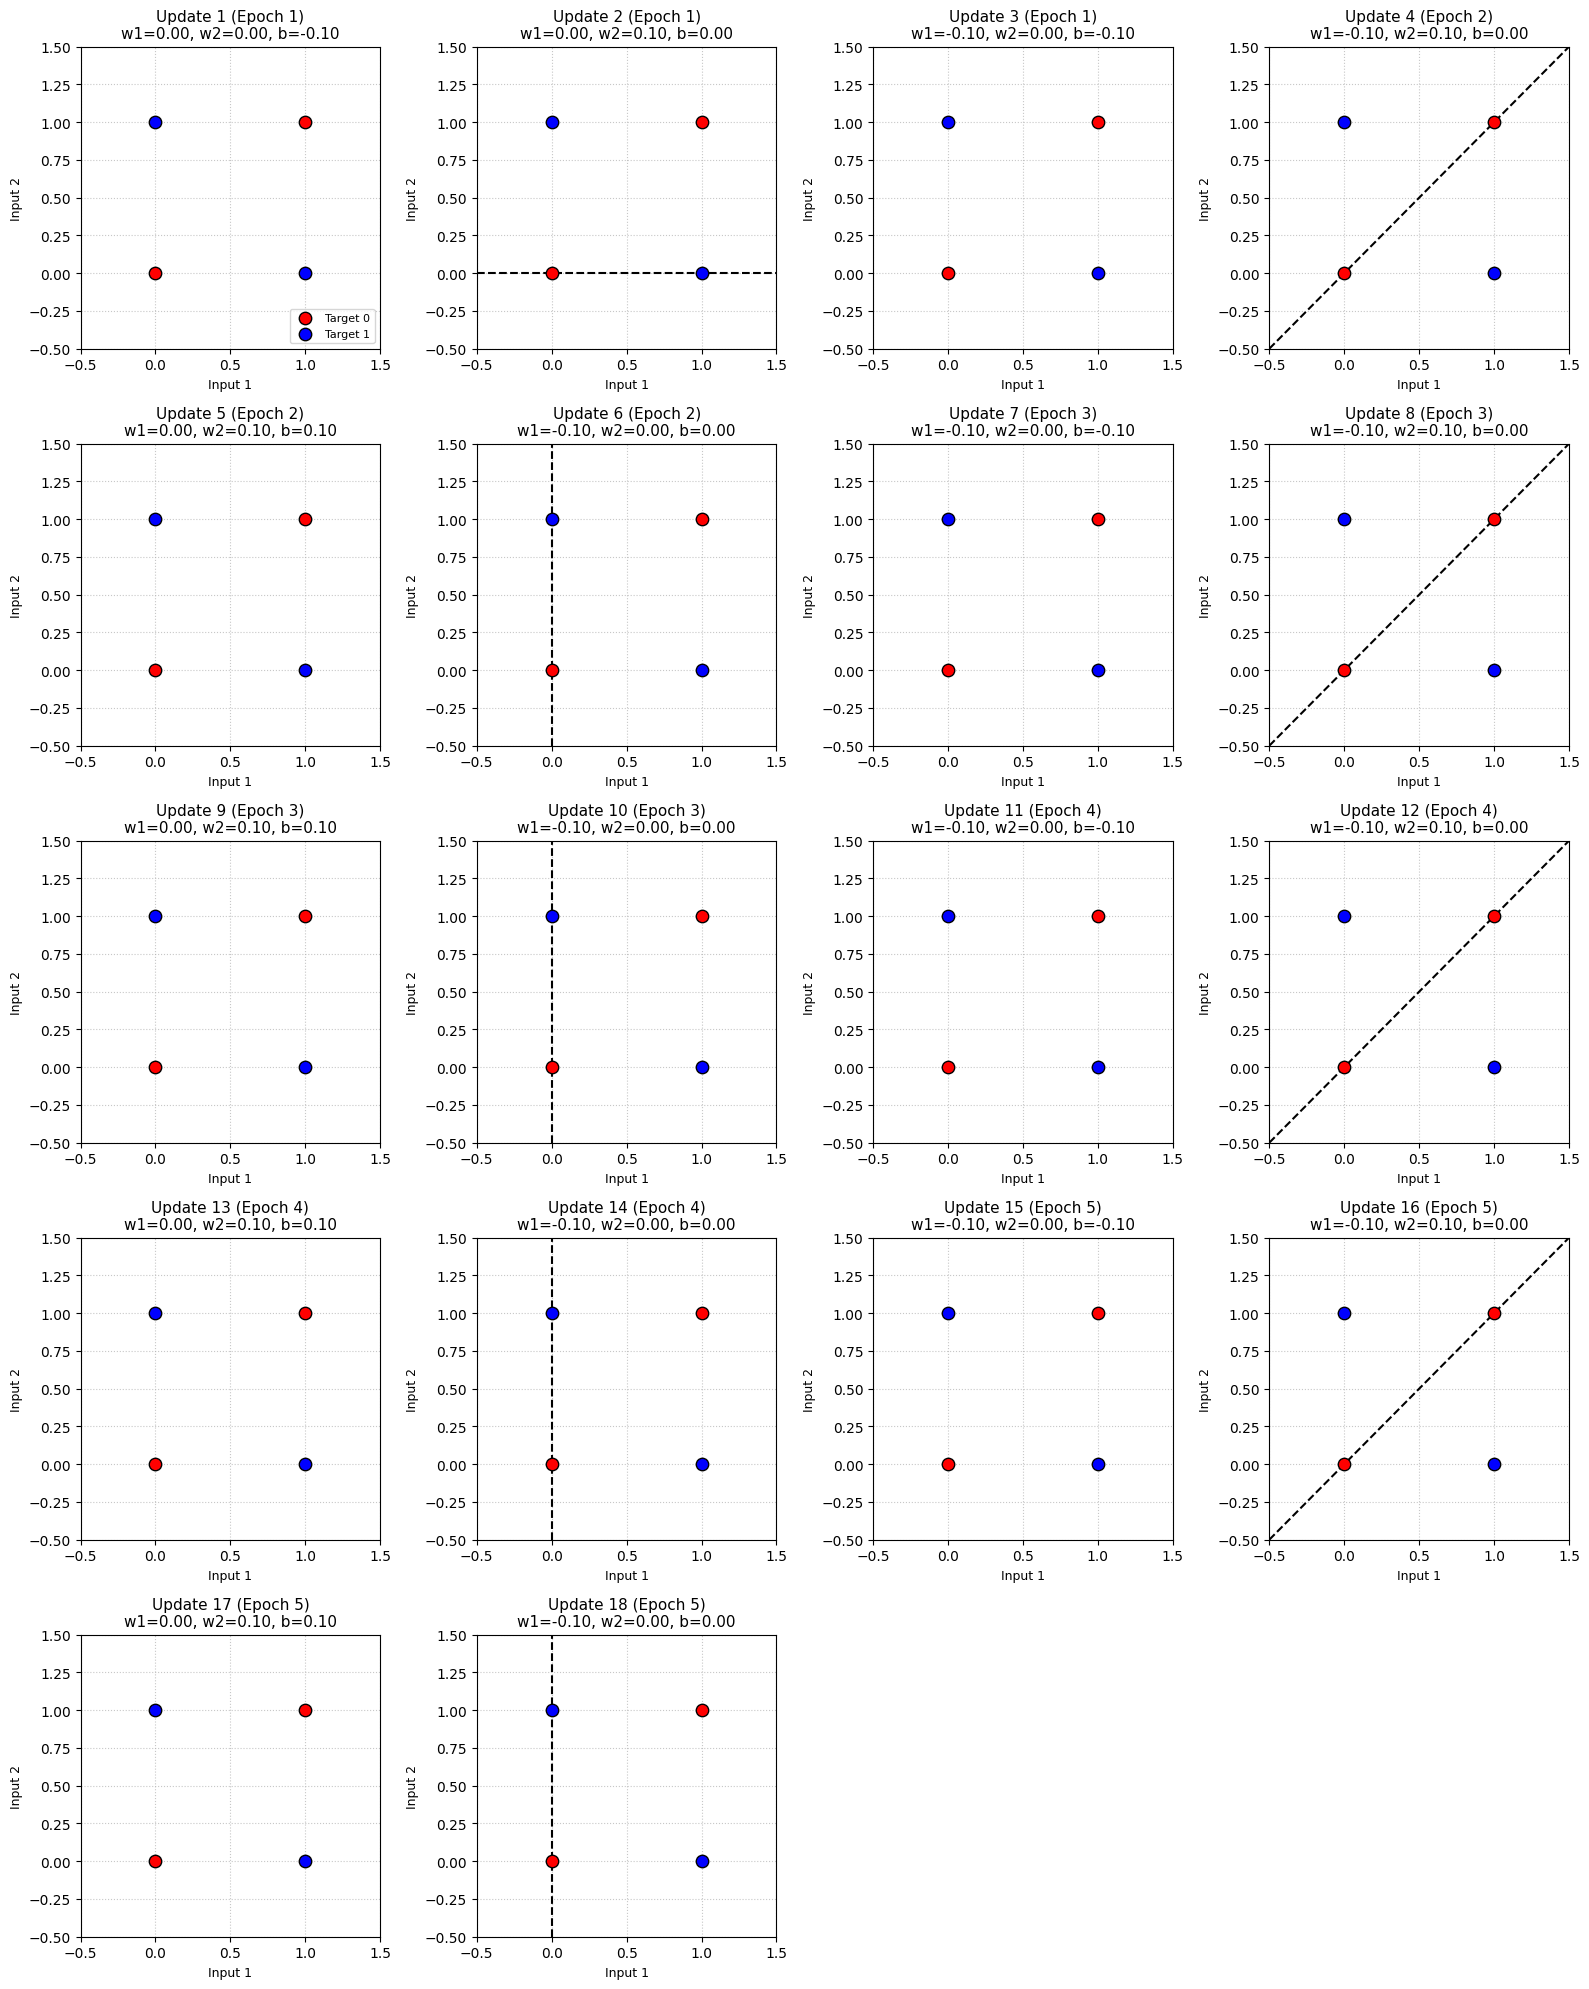

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ---------------------------------------------------------
# 1. Activation Function
# ---------------------------------------------------------
def step_function(z):
    """Step activation function: returns 1 if z >= 0, else 0."""
    return 1 if z >= 0 else 0

# ---------------------------------------------------------
# 2. Training Algorithm (Saves History)
# ---------------------------------------------------------
def train_xor_and_record(lr=0.1, max_epochs=4):
    """Trains the XOR perceptron and records the state after every update."""
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    Y = np.array([0, 1, 1, 0])

    w = np.zeros(2)
    b = 0.0
    update_count = 0
    history = []

    print("="*55)
    print("Training XOR Gate & Recording Updates (Max Epochs: 5)")
    print("="*55)

    for epoch in range(max_epochs):
        errors = 0
        for i in range(len(X)):
            z = np.dot(X[i], w) + b
            y_pred = step_function(z)

            error = Y[i] - y_pred

            if error != 0:
                w = w + lr * error * X[i]
                b = b + lr * error

                update_count += 1
                errors += 1

                # Print to console
                print(f"Epoch {epoch+1} | Update {update_count:2d}: Input {X[i]} -> Target {Y[i]} | Weights: [{w[0]:.2f}, {w[1]:.2f}], Bias: {b:.2f}")

                # Save state for the grid plot
                history.append({
                    'epoch': epoch + 1,
                    'update': update_count,
                    'w': w.copy(),
                    'b': b
                })

    return history, X, Y

# ---------------------------------------------------------
# 3. Grid Plotting Function (4 Columns per Row)
# ---------------------------------------------------------
def plot_decision_boundary_grid(history, X, Y):
    """Plots all recorded updates in a grid format (4 plots per line)."""
    n_plots = len(history)
    cols = 4
    rows = math.ceil(n_plots / cols)

    # Create a large figure based on the number of rows needed
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten() # Flatten to loop easily

    for i, record in enumerate(history):
        ax = axes[i]
        w = record['w']
        b = record['b']

        # Scatter plot classes
        ax.scatter(X[Y == 0][:, 0], X[Y == 0][:, 1], color='red', label='Target 0', s=80, edgecolors='k', zorder=3)
        ax.scatter(X[Y == 1][:, 0], X[Y == 1][:, 1], color='blue', label='Target 1', s=80, edgecolors='k', zorder=3)

        x_min, x_max = -0.5, 1.5
        y_min, y_max = -0.5, 1.5

        # Draw Decision Boundary (if weights are not completely zero)
        if w[1] != 0:
            x_vals = np.array([x_min, x_max])
            y_vals = -(w[0] * x_vals + b) / w[1]
            ax.plot(x_vals, y_vals, 'k--', linewidth=1.5)
        elif w[0] != 0:
            ax.axvline(x=-b / w[0], color='k', linestyle='--', linewidth=1.5)

        # Format the subplot
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_title(f"Update {record['update']} (Epoch {record['epoch']})\nw1={w[0]:.2f}, w2={w[1]:.2f}, b={b:.2f}", fontsize=11)
        ax.set_xlabel("Input 1", fontsize=9)
        ax.set_ylabel("Input 2", fontsize=9)
        ax.grid(True, linestyle=':', alpha=0.7)

        # Only add a legend to the very first plot to keep the grid clean
        if i == 0:
            ax.legend(loc='lower right', fontsize=8)

    # Hide any empty subplots if the total updates aren't a perfect multiple of 4
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    # Save a high-res version locally just in case
    plt.savefig("xor_updates_grid.png", dpi=300, bbox_inches='tight')
    plt.show()

# ---------------------------------------------------------
# 4. Execute
# ---------------------------------------------------------
history, X, Y = train_xor_and_record(lr=0.1, max_epochs=5)
#print("\nGenerating 4-column grid plot for report...")
plot_decision_boundary_grid(history, X, Y)